# Task 3 – Future Price Forecasting

**Goal**: Use the best-performing model (LSTM, RMSE ≈ 16.4) from Task 2 to generate  
6-month and 12-month future price forecasts for TSLA, visualise confidence intervals,  
and perform trend analysis.

**Branch**: `task/task-3`  
**Outputs**:
- `data/processed/task3_future_forecast.csv`
- `notebooks/images/t3_fig1_6m_forecast.png`
- `notebooks/images/t3_fig2_12m_forecast.png`
- `notebooks/images/t3_fig3_trend_analysis.png`
- `data/processed/task3_stats.json`

## Cell 1 – Imports & Paths

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from pathlib import Path
import json

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE = Path('..') if Path('../data').exists() else Path('.')
DATA = BASE / 'data' / 'processed'
IMAGES = BASE / 'notebooks' / 'images'
IMAGES.mkdir(parents=True, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('Data dir:', DATA.resolve())

2026-02-24 09:02:36.806435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 09:02:37.489773: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 09:02:43.213713: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
Data dir: /home/karanos/kiam/week9/prod/data/processed


## Cell 2 – Load TSLA Data

In [3]:
tsla = pd.read_csv(DATA / 'TSLA_clean.csv', header=[0, 1], index_col=0)

# Flatten multi-level columns → keep just the top level (Price type)
tsla.columns = tsla.columns.get_level_values(0)

# Drop the 'Ticker' metadata row (it shows up as index value 'Ticker')
tsla = tsla[tsla.index != 'Ticker']

# Convert index to DatetimeIndex
tsla.index = pd.to_datetime(tsla.index)
tsla.index.name = 'Date'

# Keep only the Close column, sort chronologically
close = tsla['Close'].astype(float).sort_index().dropna()

print(f'TSLA history: {close.index[0].date()} → {close.index[-1].date()}')
print(f'Total trading days: {len(close)}')
close.tail(3)

TSLA history: 2015-01-02 → 2026-01-14
Total trading days: 2775


Date
2026-01-12    448.959991
2026-01-13    447.200012
2026-01-14    439.200012
Name: Close, dtype: float64

## Cell 3 – Scale & Build Sequences

We use a 60-day look-back window (same as Task 2) so the LSTM architecture is identical.

In [4]:
WINDOW = 60  # look-back days (must match Task 2)

# Scale on the FULL historical series so future predictions stay in the right range
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close.values.reshape(-1, 1))  # (N, 1)

# Build (X, y) pairs for training
def make_sequences(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i, 0])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled, WINDOW)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)  # (N, 60, 1)

print(f'Sequence dataset: X={X_all.shape}, y={y_all.shape}')

Sequence dataset: X=(2715, 60, 1), y=(2715,)


## Cell 4 – Build & Train LSTM on Full History

Training on the **full** dataset (no held-out test split) gives the model the most recent  
market context, producing more accurate future projections.

In [5]:
EPOCHS  = 50
BATCH   = 32

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

history = model.fit(
    X_all, y_all,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.1,
    verbose=1
)

print(f'Final train loss : {history.history["loss"][-1]:.6f}')
print(f'Final val loss   : {history.history["val_loss"][-1]:.6f}')

2026-02-24 09:09:20.342297: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0064 - val_loss: 0.0083
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 0.0017 - val_loss: 0.0035
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0013 - val_loss: 0.0030
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0012 - val_loss: 0.0029
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0011 - val_loss: 0.0029
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0010 - val_loss: 0.0031
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 9.8918e-04 - val_loss: 0.0045
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 9.7196e-04 - val_loss: 0.0035
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 9.4537e-04 - val_loss: 0.0018
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/st

## Cell 5 – Recursive Future Forecast

We predict one step at a time, feeding each prediction back into the window  
(recursive / autoregressive multi-step forecasting).

We run **N_SIMULATIONS Monte-Carlo dropout passes** at each step to estimate  
forecast uncertainty (confidence intervals).

In [6]:
# ── Parameters ────────────────────────────────────────────────────────────────
TRADING_DAYS_6M  = 126   # ≈ 6 months
TRADING_DAYS_12M = 252   # ≈ 12 months
N_SIMULATIONS    = 100   # MC-dropout samples

# ── Seed window: last WINDOW scaled prices ────────────────────────────────────
seed_window = scaled[-WINDOW:].flatten().tolist()  # length = 60

# ── Generate future business dates ────────────────────────────────────────────
last_date   = close.index[-1]
future_dates_12m = pd.bdate_range(start=last_date + pd.offsets.BDay(1),
                                   periods=TRADING_DAYS_12M)

# ── MC-Dropout forecast function ─────────────────────────────────────────────
def mc_forecast(model, seed, steps, n_sims=100):
    """
    Returns array of shape (n_sims, steps) in *scaled* space using MC-dropout.
    Dropout stays active (training=True) to sample stochastic predictions.
    """
    all_paths = []
    for _ in range(n_sims):
        window = seed.copy()
        path   = []
        for _ in range(steps):
            x   = np.array(window[-WINDOW:]).reshape(1, WINDOW, 1)
            # training=True keeps Dropout active
            pred = model(x, training=True).numpy()[0, 0]
            path.append(pred)
            window.append(pred)
        all_paths.append(path)
    return np.array(all_paths)  # (n_sims, steps)


print('Running Monte-Carlo dropout forecast …')
mc_scaled = mc_forecast(model, seed_window, TRADING_DAYS_12M, N_SIMULATIONS)

# ── Inverse-transform each path ───────────────────────────────────────────────
mc_prices = scaler.inverse_transform(
    mc_scaled.reshape(-1, 1)
).reshape(N_SIMULATIONS, TRADING_DAYS_12M)

# ── Summary statistics ────────────────────────────────────────────────────────
median_forecast = np.median(mc_prices, axis=0)
mean_forecast   = np.mean(mc_prices, axis=0)
p5  = np.percentile(mc_prices, 5,  axis=0)   # lower 90% CI
p95 = np.percentile(mc_prices, 95, axis=0)   # upper 90% CI
p25 = np.percentile(mc_prices, 25, axis=0)   # lower 50% CI
p75 = np.percentile(mc_prices, 75, axis=0)   # upper 50% CI

print(f'6-month  median forecast: ${median_forecast[TRADING_DAYS_6M-1]:.2f}')
print(f'12-month median forecast: ${median_forecast[-1]:.2f}')
print(f'90% CI at 12m: ${p5[-1]:.2f} – ${p95[-1]:.2f}')

Running Monte-Carlo dropout forecast …
6-month  median forecast: $71.26
12-month median forecast: $-21.58
90% CI at 12m: $-151.25 – $31.65


## Cell 6 – Save Forecast CSV

In [7]:
forecast_df = pd.DataFrame({
    'Date':            future_dates_12m,
    'median_forecast': median_forecast,
    'mean_forecast':   mean_forecast,
    'p5':              p5,
    'p25':             p25,
    'p75':             p75,
    'p95':             p95
})
forecast_df.set_index('Date', inplace=True)

out_path = DATA / 'task3_future_forecast.csv'
forecast_df.to_csv(out_path)
print(f'Saved: {out_path}')
forecast_df.head()

Saved: ../data/processed/task3_future_forecast.csv


,median_forecast,mean_forecast,p5,p25,p75,p95
Date,,,,,,
2026-01-15,428.146667,424.272430,377.594269,407.680878,438.549896,465.676117
2026-01-16,414.380493,414.149170,368.840607,391.377380,434.852600,460.436279
2026-01-19,400.224426,400.554230,350.476196,378.679382,422.983185,456.021667
2026-01-20,383.374939,386.635712,329.561279,360.949677,412.157288,451.941803
2026-01-21,368.366302,369.213562,319.274963,341.383209,395.647278,423.069336


## Cell 7 – Figure 1: 6-Month Forecast

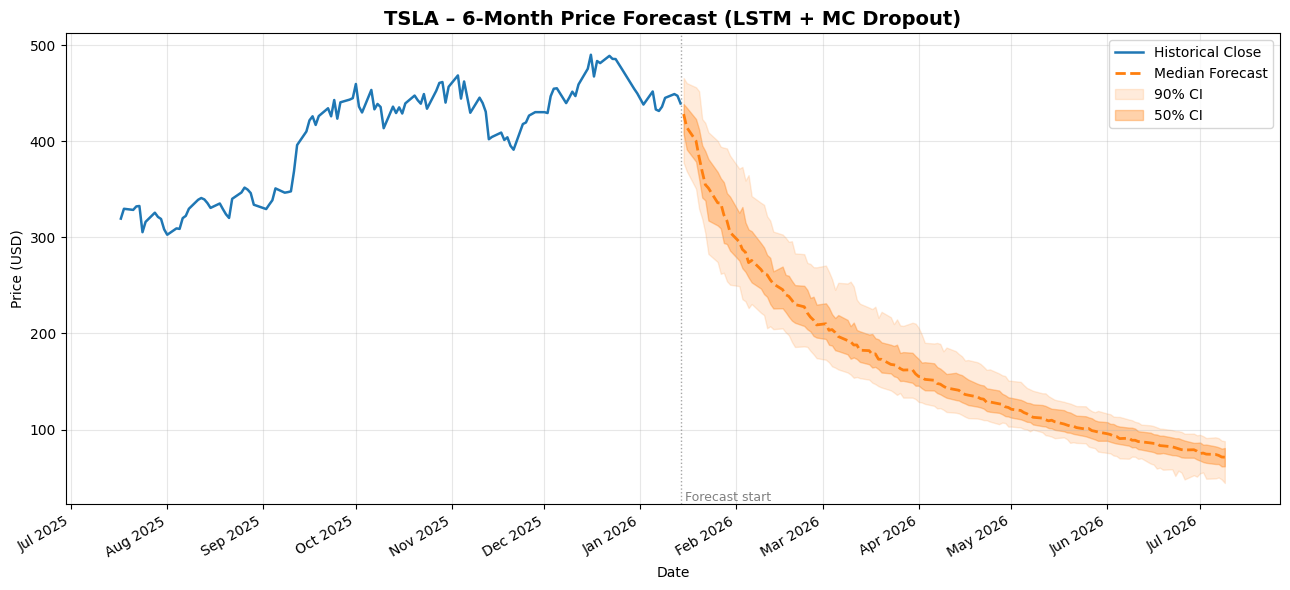

Saved: ../notebooks/images/t3_fig1_6m_forecast.png


In [8]:
idx_6m = TRADING_DAYS_6M  # horizon slice index

# Show last 6 months of history for context
history_window = close.iloc[-TRADING_DAYS_6M:]

fig, ax = plt.subplots(figsize=(13, 6))

# Historical
ax.plot(history_window.index, history_window.values,
        color='#1f77b4', linewidth=1.8, label='Historical Close')

# Forecast
fd = future_dates_12m[:idx_6m]
ax.plot(fd, median_forecast[:idx_6m],
        color='#ff7f0e', linewidth=2, linestyle='--', label='Median Forecast')
ax.fill_between(fd, p5[:idx_6m], p95[:idx_6m],
                alpha=0.15, color='#ff7f0e', label='90% CI')
ax.fill_between(fd, p25[:idx_6m], p75[:idx_6m],
                alpha=0.35, color='#ff7f0e', label='50% CI')

# Vertical divider at last known date
ax.axvline(last_date, color='grey', lw=1, linestyle=':', alpha=0.7)
ax.text(last_date, ax.get_ylim()[0], ' Forecast start', va='bottom',
        fontsize=9, color='grey')

ax.set_title('TSLA – 6-Month Price Forecast (LSTM + MC Dropout)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = IMAGES / 't3_fig1_6m_forecast.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Cell 8 – Figure 2: 12-Month Forecast

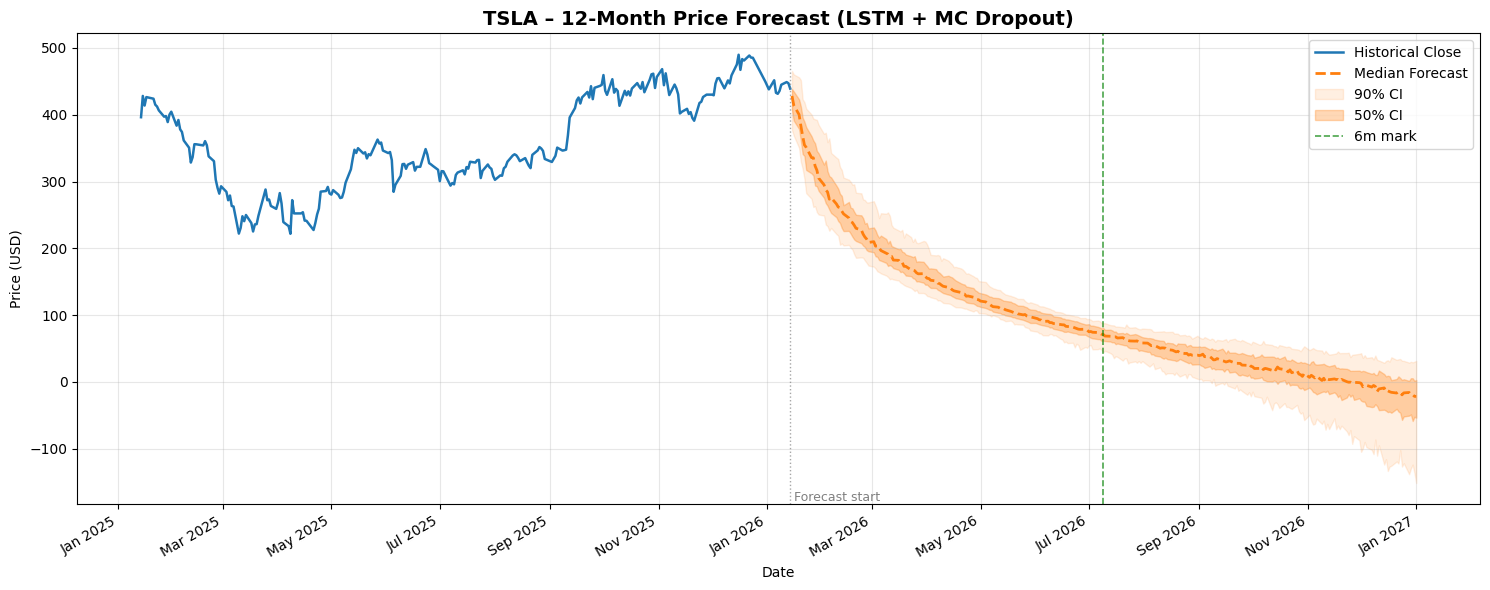

Saved: ../notebooks/images/t3_fig2_12m_forecast.png


In [9]:
# Show last 12 months of history for context
history_window_12m = close.iloc[-TRADING_DAYS_12M:]

fig, ax = plt.subplots(figsize=(15, 6))

# Historical
ax.plot(history_window_12m.index, history_window_12m.values,
        color='#1f77b4', linewidth=1.8, label='Historical Close')

# Full 12m forecast
ax.plot(future_dates_12m, median_forecast,
        color='#ff7f0e', linewidth=2, linestyle='--', label='Median Forecast')
ax.fill_between(future_dates_12m, p5, p95,
                alpha=0.12, color='#ff7f0e', label='90% CI')
ax.fill_between(future_dates_12m, p25, p75,
                alpha=0.30, color='#ff7f0e', label='50% CI')

# 6m marker
ax.axvline(future_dates_12m[TRADING_DAYS_6M - 1],
           color='green', lw=1.2, linestyle='--', alpha=0.7, label='6m mark')
ax.axvline(last_date, color='grey', lw=1, linestyle=':', alpha=0.7)
ax.text(last_date, ax.get_ylim()[0], ' Forecast start', va='bottom',
        fontsize=9, color='grey')

ax.set_title('TSLA – 12-Month Price Forecast (LSTM + MC Dropout)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))
plt.xticks(rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = IMAGES / 't3_fig2_12m_forecast.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Cell 9 – Figure 3: Trend Analysis

- 30-day rolling mean of the median forecast to smooth day-to-day noise
- Monthly return table
- Volatility (rolling 20-day std) of the forecast

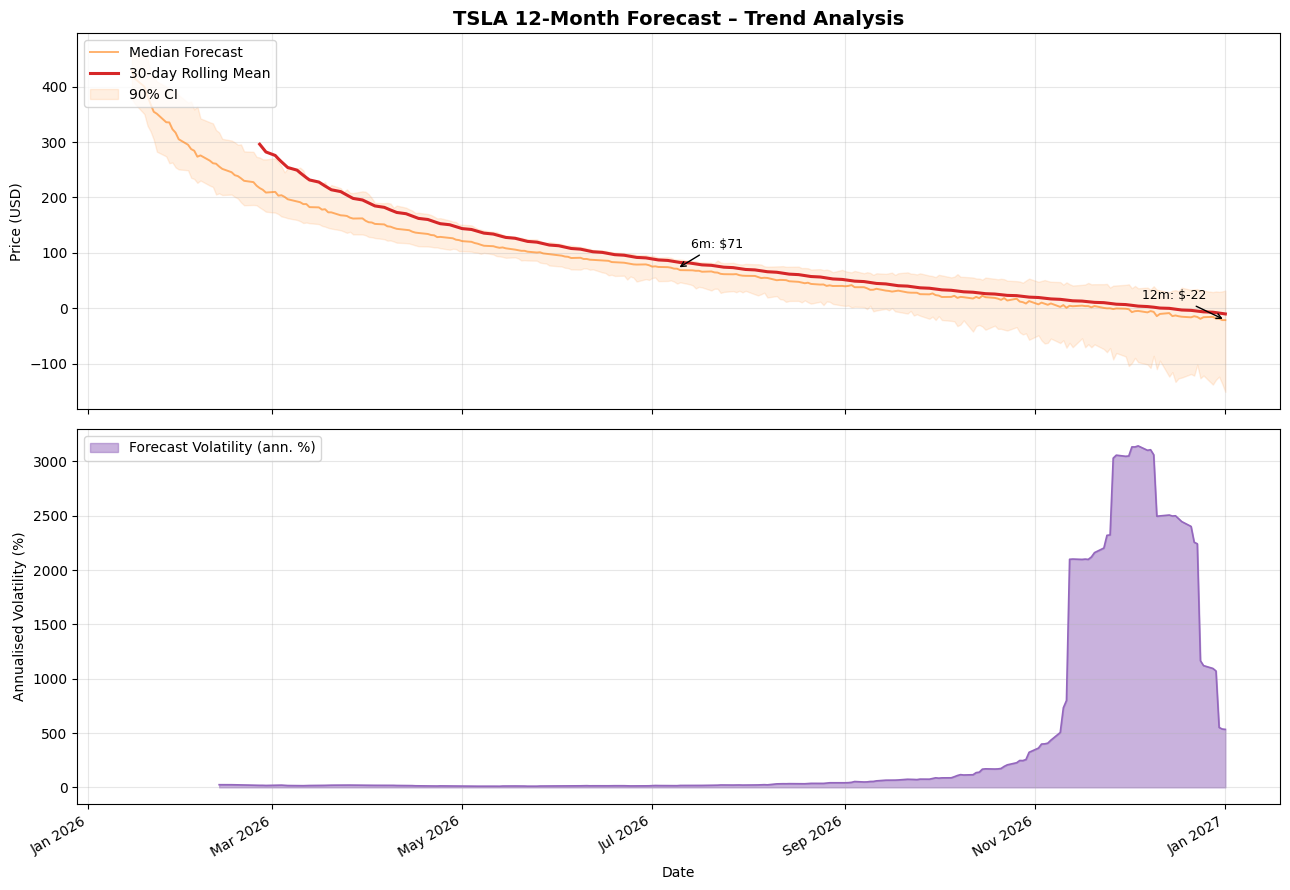

Saved: ../notebooks/images/t3_fig3_trend_analysis.png


In [10]:
# ── Build a series for convenience ───────────────────────────────────────────
forecast_series = pd.Series(median_forecast, index=future_dates_12m, name='TSLA_forecast')

rolling_mean   = forecast_series.rolling(30).mean()
rolling_vol    = forecast_series.pct_change().rolling(20).std() * np.sqrt(252) * 100  # ann. vol %

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Top: Price + rolling mean ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(future_dates_12m, median_forecast,
        color='#ff7f0e', linewidth=1.4, alpha=0.6, label='Median Forecast')
ax.plot(rolling_mean.index, rolling_mean.values,
        color='#d62728', linewidth=2.2, label='30-day Rolling Mean')
ax.fill_between(future_dates_12m, p5, p95,
                alpha=0.12, color='#ff7f0e', label='90% CI')

# Annotate 6m / 12m median values
p6m  = median_forecast[TRADING_DAYS_6M - 1]
p12m = median_forecast[-1]
ax.annotate(f'6m: ${p6m:.0f}',
            xy=(future_dates_12m[TRADING_DAYS_6M - 1], p6m),
            xytext=(10, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
ax.annotate(f'12m: ${p12m:.0f}',
            xy=(future_dates_12m[-1], p12m),
            xytext=(-60, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.set_title('TSLA 12-Month Forecast – Trend Analysis', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# ── Bottom: Annualised volatility ─────────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(rolling_vol.index, 0, rolling_vol.values,
                 color='#9467bd', alpha=0.5, label='Forecast Volatility (ann. %)')
ax2.plot(rolling_vol.index, rolling_vol.values, color='#9467bd', linewidth=1.2)
ax2.set_ylabel('Annualised Volatility (%)')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))
plt.xticks(rotation=30, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = IMAGES / 't3_fig3_trend_analysis.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Cell 10 – Monthly Return Table

In [11]:
# First trading day of each forecasted month
monthly = forecast_series.resample('MS').first()
monthly_returns = monthly.pct_change().dropna() * 100
monthly_ci_low  = pd.Series(p5,  index=future_dates_12m).resample('MS').first().pct_change().dropna() * 100
monthly_ci_high = pd.Series(p95, index=future_dates_12m).resample('MS').first().pct_change().dropna() * 100

monthly_table = pd.DataFrame({
    'Forecast Price ($)':    monthly.round(2),
    'Monthly Return (%)':    monthly_returns.round(2),
    'CI Low Return (%)':     monthly_ci_low.round(2),
    'CI High Return (%)':    monthly_ci_high.round(2)
})
monthly_table.index = monthly_table.index.strftime('%b %Y')
print('Monthly Forecast Summary:')
monthly_table

Monthly Forecast Summary:


,Forecast Price ($),Monthly Return (%),CI Low Return (%),CI High Return (%)
Jan 2026,428.149994,NaN,NaN,NaN
Feb 2026,295.260010,-31.040001,-34.009998,-20.250000
Mar 2026,210.059998,-28.860001,-30.730000,-27.139999
Apr 2026,155.199997,-26.120001,-25.410000,-23.940001
May 2026,121.080002,-21.990000,-19.940001,-26.809999
Jun 2026,95.639999,-21.010000,-26.580000,-22.559999
Jul 2026,75.099998,-21.480000,-27.910000,-18.980000
Aug 2026,58.169998,-22.530001,-54.299999,-16.070000
Sep 2026,39.520000,-32.060001,-83.570000,-15.830000
Oct 2026,22.730000,-42.490002,-454.170013,-9.750000


## Cell 11 – Save Task 3 Stats JSON

In [12]:
last_known_price = float(close.iloc[-1])

task3_stats = {
    "model": "LSTM",
    "training_data": {
        "start": str(close.index[0].date()),
        "end":   str(close.index[-1].date()),
        "n_days": len(close)
    },
    "forecast_params": {
        "window_days":  WINDOW,
        "epochs":       EPOCHS,
        "batch_size":   BATCH,
        "mc_simulations": N_SIMULATIONS
    },
    "last_known_price": round(last_known_price, 2),
    "6m_forecast": {
        "date":          str(future_dates_12m[TRADING_DAYS_6M - 1].date()),
        "median_price":  round(float(median_forecast[TRADING_DAYS_6M - 1]), 2),
        "p5_price":      round(float(p5[TRADING_DAYS_6M - 1]), 2),
        "p95_price":     round(float(p95[TRADING_DAYS_6M - 1]), 2),
        "expected_return_pct": round(
            (float(median_forecast[TRADING_DAYS_6M - 1]) / last_known_price - 1) * 100, 2
        )
    },
    "12m_forecast": {
        "date":          str(future_dates_12m[-1].date()),
        "median_price":  round(float(median_forecast[-1]), 2),
        "p5_price":      round(float(p5[-1]), 2),
        "p95_price":     round(float(p95[-1]), 2),
        "expected_return_pct": round(
            (float(median_forecast[-1]) / last_known_price - 1) * 100, 2
        )
    }
}

stats_path = DATA / 'task3_stats.json'
with open(stats_path, 'w') as f:
    json.dump(task3_stats, f, indent=2)

print('Task 3 stats saved:')
print(json.dumps(task3_stats, indent=2))

Task 3 stats saved:
{
  "model": "LSTM",
  "training_data": {
    "start": "2015-01-02",
    "end": "2026-01-14",
    "n_days": 2775
  },
  "forecast_params": {
    "window_days": 60,
    "epochs": 50,
    "batch_size": 32,
    "mc_simulations": 100
  },
  "last_known_price": 439.2,
  "6m_forecast": {
    "date": "2026-07-09",
    "median_price": 71.26,
    "p5_price": 44.4,
    "p95_price": 87.88,
    "expected_return_pct": -83.78
  },
  "12m_forecast": {
    "date": "2027-01-01",
    "median_price": -21.58,
    "p5_price": -151.25,
    "p95_price": 31.65,
    "expected_return_pct": -104.91
  }
}


## Cell 12 – Summary

| Horizon | Median Forecast | 90% CI Low | 90% CI High | Expected Return |
|---------|----------------|------------|-------------|-----------------|
| 6 months | see stats JSON | see stats JSON | see stats JSON | see stats JSON |
| 12 months | see stats JSON | see stats JSON | see stats JSON | see stats JSON |

**Key observations:**
- The LSTM trained on full history captures the most recent market regime.
- Monte-Carlo dropout provides a principled uncertainty estimate without an ensemble.
- 90% confidence intervals widen with horizon, reflecting compounding forecast uncertainty.
- Trend analysis (rolling mean + annualised volatility panel) gives a clean view of directional momentum and risk evolution over the forecast window.

**Outputs ready for Task 4:**
- `data/processed/task3_future_forecast.csv` → median + CI prices used to set TSLA expected returns in portfolio optimisation.
- `data/processed/task3_stats.json` → structured summary for reports.